# Ignore this part and go down to inference part

In [2]:
import json
import os
import time
import traceback
import typing
from datetime import datetime
from pathlib import Path

import lightning as L
import torch
from dotenv import load_dotenv
from lightning.fabric import Fabric
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger, WandbLogger
from pytorch_toolbelt.utils import count_parameters, transfer_weights, is_dist_avail_and_initialized
from transformers import (
    HfArgumentParser,
)

from cryoet.data.detection.data_module import ObjectDetectionDataModule
from cryoet.ensembling import average_checkpoints, trace_model_and_save
from cryoet.modelling.detection.convnext import ConvNextForObjectDetectionConfig, ConvNextForObjectDetection
from cryoet.modelling.detection.dynunet import DynUNetForObjectDetectionConfig, DynUNetForObjectDetection
from cryoet.modelling.detection.litehrnet import HRNetv2ForObjectDetection, HRNetv2ForObjectDetectionConfig
from cryoet.modelling.detection.segresnet_object_detection_s1 import (
    SegResNetForObjectDetectionS1,
    SegResNetForObjectDetectionS1Config,
)
from cryoet.modelling.detection.segresnet_object_detection_v2 import (
    SegResNetForObjectDetectionV2,
    SegResNetForObjectDetectionV2Config,
)
from cryoet.training.args import MyTrainingArguments, ModelArguments, DataArguments
from cryoet.training.ema import BetaDecay, EMACallback
from cryoet.training.object_detection_module import ObjectDetectionModel

/home/yousef.metwally/applications/miniforge3/envs/OD/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/yousef.metwally/applications/miniforge3/envs/OD/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
def build_model_name_slug(data_args, model_args, training_args):
    num_classes = 6 if model_args.use_6_classes else 5
    model_name_slug = f"{model_args.model_name}_fold_{data_args.fold}_{num_classes}x{model_args.train_depth_window_size}x{model_args.train_spatial_window_size}x{model_args.train_spatial_window_size}"
    if data_args.normalization != "minmax":
        model_name_slug += f"_{data_args.normalization}"
    if data_args.use_sliding_crops:
        model_name_slug += "_sc"
    if data_args.use_random_crops:
        model_name_slug += "_rc"
    if data_args.use_instance_crops:
        model_name_slug += "_ic"
    if model_args.use_stride2:
        model_name_slug += "_s2"
    if model_args.use_stride4:
        model_name_slug += "_s4"
    if not model_args.use_centernet_nms:
        model_name_slug += "_no_nms"
    if not model_args.use_offset_head:
        model_name_slug += "_no_offset"
    if model_args.use_single_label_per_anchor:
        model_name_slug += "_slpa"
    if data_args.train_modes != "denoised":
        model_name_slug += "_" + data_args.train_modes.replace(",", "_")
    if data_args.copy_paste_prob > 0:
        model_name_slug += f"_copy_{data_args.copy_paste_prob}x{data_args.copy_paste_limit}"
    if data_args.random_erase_prob > 0:
        model_name_slug += f"_re_{data_args.random_erase_prob}"
    if data_args.mixup_prob > 0:
        model_name_slug += f"_mixup_{data_args.mixup_prob}"
    if model_args.use_cross_entropy_loss:
        model_name_slug += "_ce"

    return f"{training_args.version_prefix}{model_name_slug}"

In [3]:
def create_model_from_args(model_args, training_args):
    num_classes = 6 if model_args.use_6_classes else 5
    if model_args.model_name == "segresnet_s1":
        config = SegResNetForObjectDetectionS1Config(
            num_classes=num_classes,
        )
        model = SegResNetForObjectDetectionS1(config)
    elif model_args.model_name == "segresnetv2":
        config = SegResNetForObjectDetectionV2Config(
            use_stride2=model_args.use_stride2,
            use_stride4=model_args.use_stride4,
            use_offset_head=model_args.use_offset_head,
            head_dropout_prob=model_args.head_dropout_prob,
            num_classes=num_classes,
        )
        model = SegResNetForObjectDetectionV2(config)
    elif model_args.model_name == "dynunet":
        config = DynUNetForObjectDetectionConfig(
            use_stride2=model_args.use_stride2,
            use_stride4=model_args.use_stride4,
            num_classes=num_classes,
        )
        model = DynUNetForObjectDetection(config)
    elif model_args.model_name == "dynunet_v2":
        config = DynUNetForObjectDetectionConfig(
            # dropout=0.1,
            res_block=True,
            use_stride2=model_args.use_stride2,
            use_stride4=model_args.use_stride4,
            num_classes=num_classes,
            object_size=32,
            intermediate_channels=64,
            offset_intermediate_channels=8,
        )
        model = DynUNetForObjectDetection(config)
    elif model_args.model_name == "hrnet":
        config = HRNetv2ForObjectDetectionConfig(
            num_classes=num_classes,
        )
        model = HRNetv2ForObjectDetection(config)
    elif model_args.model_name == "convnext":
        config = ConvNextForObjectDetectionConfig(
            num_classes=num_classes,
        )
        model = ConvNextForObjectDetection(config)
    # elif model_args.model_name == "unet3d":
    #     config = UNet3DForObjectDetectionConfig(window_size=model_args.window_size)
    #     model = UNet3DForObjectDetection(config)
    # elif model_args.model_name == "maxvit_nano_unet25d":
    #     config = MaxVitUnet25dConfig(img_size=model_args.window_size)
    #     model = MaxVitUnet25d(config)
    # elif model_args.model_name == "unet3d-fat":
    #     config = UNet3DForObjectDetectionConfig(
    #         encoder_channels=[32, 64, 128, 256],
    #         num_blocks_per_stage=(2, 3, 4, 6),
    #         num_blocks_per_decoder_stage=(2, 2, 2),
    #         intermediate_channels=64,
    #         offset_intermediate_channels=16,
    #         window_size=model_args.window_size,
    #     )
    #     model = UNet3DForObjectDetection(config)
    # elif model_args.model_name == "unetr":
    #     config = SwinUNETRForObjectDetectionConfig()
    #     model = SwinUNETRForObjectDetection(config)
    else:
        raise ValueError(f"Unknown model name: {model_args.model_name}")
    if model_args.pretrained_backbone_path is not None:
        backbone_sd = torch.load(model_args.pretrained_backbone_path, weights_only=True)
        model.backbone.load_state_dict(backbone_sd, strict=True)
        training_args.master_print(f"Loaded pretrained backbone from {model_args.pretrained_backbone_path}")
    return model

In [4]:
def infer_training_precision(training_args):
    if training_args.bf16:
        return "bf16-mixed"
    if training_args.fp16:
        return "16-mixed"
    return 32

In [5]:
def infer_strategy(training_args, fabric):
    if fabric.world_size > 1:
        if training_args.ddp_find_unused_parameters:
            strategy = "ddp_find_unused_parameters_true"
        else:
            strategy = "ddp"
    else:
        strategy = "auto"
    return strategy

In [6]:
training_args=MyTrainingArguments()

In [7]:
training_args

MyTrainingArguments(output_dir='trainer_output', overwrite_output_dir=False, do_train=False, do_eval=True, do_predict=False, eval_strategy=<IntervalStrategy.EPOCH: 'epoch'>, prediction_loss_only=False, per_device_train_batch_size=8, per_device_eval_batch_size=1, per_gpu_train_batch_size=None, per_gpu_eval_batch_size=None, gradient_accumulation_steps=1, eval_accumulation_steps=None, eval_delay=0, torch_empty_cache_steps=None, learning_rate=5e-05, weight_decay=0.0001, adam_beta1=0.9, adam_beta2=0.999, adam_epsilon=1e-08, max_grad_norm=3.0, num_train_epochs=3.0, max_steps=-1, lr_scheduler_type=<SchedulerType.LINEAR: 'linear'>, lr_scheduler_kwargs={}, warmup_ratio=0.0, warmup_steps=0, log_level='passive', log_level_replica='warning', log_on_each_node=True, logging_dir='trainer_output/runs/May28_15-18-14_m24008-lin', logging_strategy=<IntervalStrategy.STEPS: 'steps'>, logging_first_step=False, logging_steps=1, logging_nan_inf_filter=True, save_strategy=<SaveStrategy.EPOCH: 'epoch'>, save_st

In [8]:
model_args = ModelArguments()

In [9]:
data_args = DataArguments()

In [10]:
data_args

DataArguments(data_root=None, fold=0, interpolation_mode='1', split_strategy='split_data_into_folds', normalization='minmax', use_sliding_crops=False, use_random_crops=False, use_instance_crops=False, use_random_flips=True, train_modes='denoised', valid_modes='denoised', num_crops_per_study=256, scale_limit=0.05, anisotropic_scale_limit=0.0, z_rotation_limit=360.0, y_rotation_limit=0.0, x_rotation_limit=0.0, random_erase_prob=0.0, copy_paste_prob=0.0, copy_paste_limit=1, mixup_prob=0.0, gaussian_noise_sigma=0.0, use_weighted_average=False, validate_on_z_flips=False, validate_on_y_flips=False, validate_on_x_flips=False, validate_on_rot90=False)

In [11]:
training_args = typing.cast(MyTrainingArguments, training_args)
model_args = typing.cast(ModelArguments, model_args)
data_args = typing.cast(DataArguments, data_args)

In [12]:
training_args.adam_beta1 = 0.95
training_args.adam_beta2 = 0.99
training_args.average_tokens_across_devices=True
training_args.dataloader_num_workers=8
training_args.dataloader_persistent_workers=True
training_args.dataloader_pin_memory=True
training_args.ddp_find_unused_parameters=True
training_args.early_stopping=15
data_args.fold=0
training_args.learning_rate=5e-5
training_args.max_grad_norm=3
training_args.ddp_find_unused_parameters=True
model_args.model_name='segresnetv2'
training_args.num_train_epochs=75
training_args.per_device_train_batch_size=2
model_args.pretrained_backbone_path = 'pretrained/wholeBody_ct_segmentation/models/model.pt'
data_args.scale_limit = 0.05
model_args.use_6_classes = True
data_args.use_instance_crops=True
data_args.use_random_crops=True
model_args.use_stride4 = False
training_args.warmup_steps = 64
training_args.weight_decay = 0.01
data_args.y_rotation_limit=5
data_args.x_rotation_limit=5
training_args.seed=1
data_args.interpolation_mode=1
data_args.validate_on_rot90 = True

In [13]:
model_name_slug = build_model_name_slug(data_args, model_args, training_args)

In [14]:
model_name_slug

'segresnetv2_fold_0_6x96x128x128_rc_ic_s2'

In [15]:
timestamp = datetime.now().strftime("%y%m%d_%H%M")

In [16]:
if training_args.output_dir == 'trainer_output':
        output_dir_name = f"runs/{model_name_slug}"

        training_args_str = f"{training_args.optim.value}_lr_{training_args.learning_rate:.0e}_wd_{training_args.weight_decay}_b1_{training_args.adam_beta1}_b2_{training_args.adam_beta2}"
        if training_args.ema:
            training_args_str += f"_ema_{training_args.ema_decay}_{training_args.ema_beta}"

        training_args.output_dir = os.path.join(output_dir_name, f"{timestamp}_{training_args_str}")

In [17]:
model_args

ModelArguments(model_name='segresnetv2', pretrained_model_name_or_path=None, pretrained_backbone_path='pretrained/wholeBody_ct_segmentation/models/model.pt', use_qfl_loss=False, train_spatial_window_size=128, train_depth_window_size=96, valid_depth_window_size=192, valid_depth_num_tiles=1, valid_spatial_window_size=128, valid_spatial_num_tiles=7, use_centernet_nms=True, use_single_label_per_anchor=False, use_offset_head=True, use_stride4=False, use_stride2=True, use_6_classes=True, assigned_min_iou_for_anchor=0.05, assigner_max_anchors_per_point=13, assigner_alpha=1.0, assigner_beta=6.0, apply_loss_on_each_stride=False, head_dropout_prob=0.0, use_varifocal_loss=True, use_cross_entropy_loss=False)

In [18]:
training_args.master_print(f"Training arguments: {training_args}")

Training arguments: MyTrainingArguments(
_n_gpu=2,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.95,
adam_beta2=0.99,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=8,
dataloader_persistent_workers=True,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=True,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
early_stopping=15,
ema=False,
ema_beta=10,
ema_decay=0.995,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval

In [19]:
model = create_model_from_args(model_args, training_args)

Loaded pretrained backbone from pretrained/wholeBody_ct_segmentation/models/model.pt


In [20]:
training_args.master_print(f"Model parameters: {count_parameters(model, human_friendly=True)}")

Model parameters: {'total': '19.0M', 'trainable': '19.0M', 'backbone': '18.8M', 'dropout': '0', 'head2': '180.19K'}


In [21]:
data_args.data_root = '/mnt/data1/D1/Competition/czii-cryo-et-object-identification'

In [22]:
data_args.use_instance_crops = True
data_args.use_random_crops = True

In [23]:
fabric = Fabric()
with fabric.rank_zero_first():
            data_module = ObjectDetectionDataModule(
                data_args=data_args,
                train_args=training_args,
                model_args=model_args,
            )

Fabric will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Fabric(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


In [24]:
data_module.train_studies

['TS_6_4', 'TS_6_6', 'TS_73_6', 'TS_86_3', 'TS_99_9']

In [25]:
model_module = ObjectDetectionModel(model=model, data_args=data_args, model_args=model_args, train_args=training_args)

In [26]:
if training_args.transfer_weights is not None:
            checkpoint = torch.load(training_args.transfer_weights, map_location="cpu")
            transfer_weights(model_module, checkpoint["state_dict"])
            training_args.master_print(f"Loaded weights from {training_args.transfer_weights}")

In [27]:
checkpoint_callback = ModelCheckpoint(
            dirpath=training_args.output_dir,
            enable_version_counter=False,
            monitor="val/score",
            mode="max",
            save_last=True,
            auto_insert_metric_name=False,
            save_top_k=5,
            filename=f"{timestamp}_{model_name_slug}"
            + "_{step:03d}-score-{val/score:0.4f}-at-{val/apo-ferritin_threshold:0.3f}-{val/beta-galactosidase_threshold:0.3f}-{val/ribosome_threshold:0.3f}-{val/thyroglobulin_threshold:0.3f}-{val/virus-like-particle_threshold:0.3f}",
            # + "_{step:03d}-score-{val/score:0.4f}",
        )

In [28]:
report_to = training_args.report_to
if isinstance(report_to, list) and len(report_to) == 1:
            report_to = report_to[0]

In [29]:
report_to

'tensorboard'

In [30]:
loggers = []
if "tensorboard" in report_to:
            logger = TensorBoardLogger(save_dir=training_args.output_dir, name=None, version="")
            loggers.append(logger)
if "wandb" in report_to:
            logger = WandbLogger()
            loggers.append(logger)
if len(loggers) == 1:
            loggers = loggers[0]

In [31]:
loggers

In [32]:
callbacks = [checkpoint_callback]

In [33]:
if training_args.early_stopping > 0:
            callbacks.append(
                EarlyStopping(monitor="val/score", min_delta=0.001, patience=training_args.early_stopping, mode="max")
            )

In [34]:
callbacks

In [35]:
lr_monitor = LearningRateMonitor(logging_interval="step")
if "wandb" not in training_args.report_to:
            callbacks.append(lr_monitor)

precision = infer_training_precision(training_args)
fabric.print(f"Training precision: {precision}")

Training precision: bf16-mixed


In [36]:
if training_args.ema:
            callbacks.append(EMACallback(decay=BetaDecay(max_decay=training_args.ema_decay, beta=training_args.ema_beta)))
            fabric.print(f"Using EMA with decay={training_args.ema_decay} and beta={training_args.ema_beta}")

fabric.print("Batch Size:", training_args.per_device_train_batch_size, training_args.per_device_eval_batch_size)

Batch Size: 2 1


In [37]:
strategy = infer_strategy(training_args, fabric)

In [38]:
strategy

'auto'

In [39]:
trainer = L.Trainer(
            strategy=strategy,
            max_epochs=int(training_args.num_train_epochs),
            max_steps=training_args.max_steps,
            precision=precision,
            log_every_n_steps=training_args.logging_steps,
            default_root_dir=training_args.output_dir,
            callbacks=callbacks,
            accumulate_grad_batches=training_args.gradient_accumulation_steps,
            gradient_clip_val=training_args.max_grad_norm,
            logger=loggers,
        )

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(model_module, datamodule=data_module)

Flipping False False False
Added TS_5_4_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_5_4_rot90_1_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_5_4_rot90_2_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_5_4_rot90_3_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_69_2_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False


/home/yousef.metwally/applications/miniforge3/envs/OD/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/yousef.metwally/Kaggle-2024-CryoET/runs/segresnetv2_fold_0_6x96x128x128_rc_ic_s2/250528_1518_adamw_torch_lr_5e-05_wd_0.01_b1_0.95_b2_0.99 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Added TS_69_2_rot90_1_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_69_2_rot90_2_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
Added TS_69_2_rot90_3_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Validation studies: ['TS_5_4_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_1_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_2_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_3_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_1_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_2_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_3_flip_x=False_flip_y=False_flip_z=False']
Using warmup steps: 64



  | Name  | Type                          | Params | Mode 
----------------------------------------------------------------
0 | model | SegResNetForObjectDetectionV2 | 19.0 M | train
----------------------------------------------------------------
19.0 M    Trainable params
0         Non-trainable params
19.0 M    Total params
75.918    Total estimated model params size (MB)
156       Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:01<00:00,  1.84it/s]Rank 0 got local studies ['TS_5_4_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_1_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_2_flip_x=False_flip_y=False_flip_z=False', 'TS_5_4_rot90_3_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_1_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_2_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_rot90_3_flip_x=False_flip_y=False_flip_z=False']
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Final predictions after NMS: 0
Rank 0 has 0 predictions
Rank 0 has 0 predictions after all_gather
Epoch 0: 100%|██████████| 1280/1280 [08:03<00:00,  2.65it/s, train/loss_step=1.140, train/cls_loss_step=1.120, train/reg_loss_step=0.0253, t


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

: 

In [94]:
data_module

In [95]:
data_module.setup(0)

Flipping False False False
SlidingWindowCryoETObjectDetectionDataset (184, 630, 630) (192, 128, 128) (1, 7, 7)
compute_better_tiles_with_num_til 192 128 128
compute_better_tiles_with_num_til 1 7 7
compute_better_tiles_with_num_til 184 630 630
Added TS_5_4_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Flipping False False False
SlidingWindowCryoETObjectDetectionDataset (184, 630, 630) (192, 128, 128) (1, 7, 7)
compute_better_tiles_with_num_til 192 128 128
compute_better_tiles_with_num_til 1 7 7
compute_better_tiles_with_num_til 184 630 630
Added TS_69_2_flip_x=False_flip_y=False_flip_z=False objects to the dataset
Validation studies: ['TS_5_4_flip_x=False_flip_y=False_flip_z=False', 'TS_69_2_flip_x=False_flip_y=False_flip_z=False']


In [96]:
loader = data_module.train_dataloader()

In [42]:
batch = next(iter(loader))

In [43]:
batch.keys()

dict_keys(['volume', 'tile_offsets_zyx', 'volume_shape', 'study', 'mode', 'labels', 'num_items_in_batch'])

In [44]:
batch['volume'].shape

torch.Size([8, 1, 96, 128, 128])

In [45]:
batch['volume_shape']

tensor([[184, 630, 630],
        [184, 630, 630],
        [184, 630, 630],
        [184, 630, 630],
        [184, 630, 630],
        [184, 630, 630],
        [184, 630, 630],
        [184, 630, 630]])

In [46]:
batch['study']

['TS_86_3',
 'TS_73_6',
 'TS_6_4',
 'TS_86_3',
 'TS_99_9',
 'TS_6_6',
 'TS_99_9',
 'TS_99_9']

In [47]:
batch['tile_offsets_zyx']

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])

In [48]:
batch['labels'][7]

tensor([[ 118.7787,    0.9617,   33.7122,    2.0000,   15.4583],
        [  63.5000,   63.5000,   47.5000,    3.0000,   13.3972],
        [-100.0000, -100.0000, -100.0000, -100.0000, -100.0000],
        [-100.0000, -100.0000, -100.0000, -100.0000, -100.0000],
        [-100.0000, -100.0000, -100.0000, -100.0000, -100.0000],
        [-100.0000, -100.0000, -100.0000, -100.0000, -100.0000],
        [-100.0000, -100.0000, -100.0000, -100.0000, -100.0000],
        [-100.0000, -100.0000, -100.0000, -100.0000, -100.0000],
        [-100.0000, -100.0000, -100.0000, -100.0000, -100.0000],
        [-100.0000, -100.0000, -100.0000, -100.0000, -100.0000],
        [-100.0000, -100.0000, -100.0000, -100.0000, -100.0000]])

In [49]:
batch['num_items_in_batch']

tensor(37)

In [50]:
valloader = data_module.val_dataloader()

In [51]:
valbatch = next(iter(valloader))

In [52]:
valbatch['volume'].shape

torch.Size([1, 1, 192, 128, 128])

# Here starts the inference sooryyy xD

In [2]:
# inference
from ctypes import *

import os
import torch
import dataclasses
import zarr
import math

from collections import defaultdict
from pathlib import Path
from fire import Fire

import numpy as np
import pandas as pd
import torch.jit
from tqdm import tqdm

import typing
import einops

from torch import Tensor, nn
from typing import List, Tuple, Union, Any, Iterable, Optional
from torch.utils.data import Dataset, DataLoader
import onnxruntime as ort

In [3]:
import torch
#model = torch.jit.load('/home/yousef.metwally/Kaggle-2024-CryoET/all_ensemble.jit')
#model = torch.jit.load('/home/yousef.metwally/Kaggle-2024-CryoET/sim_ensemble.jit')
#model = torch.jit.load('/home/yousef.metwally/Kaggle-2024-CryoET/wbp_output/wbp_ensemble.jit')
model = torch.jit.load('/home/yousef.metwally/Kaggle-2024-CryoET/yoyo_ensemble.jit')
model.eval()
models = [model]

In [4]:
import mrcfile
def get_volume_mrc(v_path):
    with mrcfile.open(v_path, permissive=True) as mrc:
        tomo_array = mrc.data.astype(np.float32)

    return(tomo_array)

In [6]:
#volume = get_volume_mrc('/mnt/billy/abt3/group/agraunser/transfer/Thorsten/topick/01122021_BrnoKrios_arctis_lam3_pos27.mrc')
#volume = get_volume_mrc('/mnt/data2/D2/generalization_tomogram/tiltseries_rec_lp60.mrc')
volume = get_volume_mrc('/mnt/billy/abt3/group/agraunser/transfer/Thorsten/topick/17072022_BrnoKrios_Arctis_p3ar_grid_Position_35.mrc')

In [8]:
volume.shape

(512, 1024, 1024)

In [ ]:
from tqdm import tqdm
from cryoet.inference.predict_volume import *
import math
submissions = []
output_strides = (2,)
window_size = (512, 256, 256)
tiles_per_dim = (math.ceil(volume.shape[0]*1/window_size[0]),math.ceil(volume.shape[1]*1/window_size[1]),math.ceil(volume.shape[2]*1/window_size[2]))
#tiles_per_dim=(1,9,9)
use_weighted_average = True
use_centernet_nms = True
use_single_label_per_anchor = False
pre_nms_top_k = 16536*5
use_z_flip_tta = False
use_y_flip_tta = False
use_x_flip_tta = False
score_thresholds=[0.255,0.235,0.16 ,0.205,0.225, 0.5]
iou_threshold = 0.85
num_workers = 0
torch_dtype = torch.float16
device = 'cuda'
batch_size = 1
tomo = '17072022_BrnoKrios_Arctis_p3ar_grid_Position_35'
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
study_sub = predict_volume(
            volume=volume,
            study_name=tomo,
            output_strides=output_strides,
            models= models,
            window_size=window_size,
            tiles_per_dim=tiles_per_dim,
            use_weighted_average=use_weighted_average,
            use_centernet_nms=use_centernet_nms,
            use_single_label_per_anchor=use_single_label_per_anchor,
            pre_nms_top_k=None,

            use_z_flip_tta=use_z_flip_tta,
            use_y_flip_tta=use_y_flip_tta,
            use_x_flip_tta=use_x_flip_tta,

            score_thresholds=[0.005],
            iou_threshold=0.6,

            batch_size=batch_size,
            num_workers=num_workers,

            device=device,
            torch_dtype=torch_dtype,
        )

/home/yousef.metwally/applications/miniforge3/envs/OD/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
TS_5_4 (512, 1024, 1024):   6%|▋         | 1/16 [00:12<03:10, 12.68s/it]

Num classes 1


TS_5_4 (512, 1024, 1024): 100%|██████████| 16/16 [02:29<00:00,  9.32s/it]


num_classes 1
362481
Predictions for class 0 after NMS 307198
Final predictions after NMS: 307198


In [163]:
study_sub

,experiment,particle_type,score,x,y,z
0,TS_5_4,apo-ferritin,0.999023,1257.865112,5462.259766,734.229614
1,TS_5_4,apo-ferritin,0.997559,3280.924561,3019.048340,671.488403
2,TS_5_4,apo-ferritin,0.996582,2599.746826,3727.206543,877.369934
3,TS_5_4,apo-ferritin,0.995605,4806.517578,469.773254,527.135742
4,TS_5_4,apo-ferritin,0.995117,616.354004,1155.515869,632.210388
...,...,...,...,...,...,...
65719,TS_5_4,apo-ferritin,0.008949,3512.471680,6302.603027,229.465088
65720,TS_5_4,apo-ferritin,0.008919,0.000000,6295.169922,850.668640
65721,TS_5_4,apo-ferritin,0.008347,5252.186035,6303.722656,248.395859
65722,TS_5_4,apo-ferritin,0.008125,5638.412109,6301.097168,747.996155


In [11]:
score_thresholds = np.linspace(0,0.5,100)
picks = []
for i in score_thresholds:
    picks.append(len(study_sub[(study_sub['score']>i)]))
p = np.array(picks)
fst = np.gradient(p)
snd = np.gradient(fst)

56234


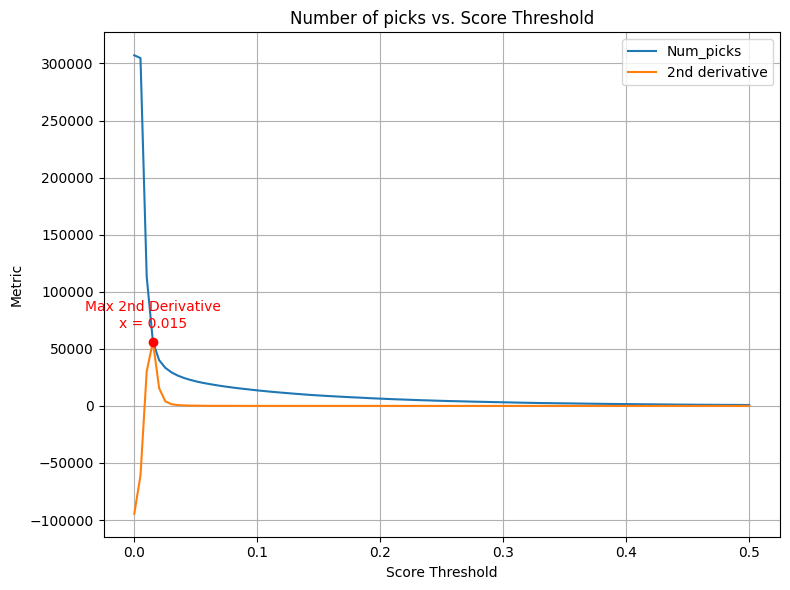

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'score_thresholds', 'picks', and 'snd' are already defined lists or arrays

# Find the index of the maximum second derivative
max_snd_idx = np.argmax(snd)
max_snd_value = snd[max_snd_idx]
corresponding_threshold = score_thresholds[max_snd_idx]
corresponding_picks = picks[max_snd_idx]
print(corresponding_picks)
# Plotting
plt.figure(figsize=(8,6))
plt.plot(score_thresholds, picks, label='Num_picks')
#plt.plot(score_thresholds, fst, label='1st derivative')
plt.plot(score_thresholds, snd, label='2nd derivative')

# Annotate the max second derivative point
plt.scatter(corresponding_threshold, max_snd_value, color='red', zorder=5)
plt.annotate(
    f"Max 2nd Derivative\nx = {corresponding_threshold:.3f}", 
    (corresponding_threshold, max_snd_value),
    textcoords="offset points", xytext=(0,10), ha='center', color='red'
)

plt.xlabel("Score Threshold")
plt.ylabel("Metric")
plt.title("Number of picks vs. Score Threshold")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(f"/home/yousef.metwally/Kaggle-2024-CryoET/yoyo_output/{tomo}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = f"/home/yousef.metwally/Kaggle-2024-CryoET/wbp_output/{tomo}_peak_submission.csv"

study_sub[(study_sub['score']>corresponding_threshold)].to_csv(f"{CSV_PATH}", index=False)
submission = pd.read_csv(CSV_PATH)
pixel_size = 10.012
submission[['x', 'y','z']] = submission[['x', 'y','z']] / pixel_size
submission[['x', 'y','z']] = submission[['x', 'y','z']].astype(int)
submission = submission[(submission['z'] != 0) & (submission['z'] != volume.shape[0])]


grouped = submission.groupby(['experiment', 'particle_type'])
for (experiment_id, particle_type), group in grouped:
    coords_file = OUTPUT_DIR / f"{experiment_id}_{corresponding_threshold:.04f}_peak.coords"
    group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

print(f"Saved .coords files in {OUTPUT_DIR.resolve()}")

Saved .coords files in /home/yousef.metwally/Kaggle-2024-CryoET/yoyo_output/17072022_BrnoKrios_Arctis_p3ar_grid_Position_35


: 

In [35]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(f"/home/yousef.metwally/Kaggle-2024-CryoET/yoyo_output/{tomo}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = f"/home/yousef.metwally/Kaggle-2024-CryoET/wbp_output/{tomo}_peak_submission.csv"
for threshold in score_thresholds:
        study_sub[(study_sub['score']>threshold)].to_csv(f"{CSV_PATH}", index=False)
        submission = pd.read_csv(CSV_PATH)
        pixel_size = 10.012
        submission[['x', 'y','z']] = submission[['x', 'y','z']] / pixel_size
        submission[['x', 'y','z']] = submission[['x', 'y','z']].astype(int)


        grouped = submission.groupby(['experiment', 'particle_type'])
        for (experiment_id, particle_type), group in grouped:
                coords_file = OUTPUT_DIR / f"{experiment_id}_{threshold:.04f}.coords"
                group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

print(f"Saved .coords files in {OUTPUT_DIR.resolve()}")


Saved .coords files in /home/yousef.metwally/Kaggle-2024-CryoET/yoyo_output/01122021_BrnoKrios_arctis_lam3_pos27


In [ ]:
def read_boxes(filename):
    boxes = []
    with open(filename, 'r') as f:
        for line in f:
            x, y, z = map(float, line.strip().split())
            boxes.append((x, y, z))
    return boxes

def calculate_iou(box1, box2, box_size=20):
    x1, y1, z1 = box1
    x2, y2, z2 = box2
    
    # Calculate intersection bounds
    x_left = max(x1 - box_size/2, x2 - box_size/2)
    x_right = min(x1 + box_size/2, x2 + box_size/2)
    y_bottom = max(y1 - box_size/2, y2 - box_size/2)
    y_top = min(y1 + box_size/2, y2 + box_size/2)
    z_front = max(z1 - box_size/2, z2 - box_size/2)
    z_back = min(z1 + box_size/2, z2 + box_size/2)
    
    # Calculate intersection volume
    intersection = 0
    if x_left < x_right and y_bottom < y_top and z_front < z_back:
        width = x_right - x_left
        height = y_top - y_bottom
        depth = z_back - z_front
        intersection = width * height * depth
    
    # Calculate union volume
    volume1 = box_size ** 3
    volume2 = box_size ** 3
    union = volume1 + volume2 - intersection
    
    return intersection / union if union != 0 else 0

# Read ground truth and experimental boxes
#ground_truth_boxes = read_boxes('/home/yousef.metwally/Downloads/toxin/toxin_manual_refined.coords')
#ground_truth_boxes = read_boxes('/mnt/data2/D2/generalization_tomogram/coords/gt.coords')
ground_truth_boxes = read_boxes('/mnt/data2/D2/OD/Data/validation/TS_5_4/coords/TS_5_4.coords')
experimental_boxes = read_boxes('/home/yousef.metwally/Kaggle-2024-CryoET/wbp_output/TS_5_4/TS_5_4_0.0253_peak.coords')

# Initialize matched list
matched = [False] * len(ground_truth_boxes)

tp = 0
iou_threshold = 0.5

for exp_box in experimental_boxes:
    best_iou = 0
    best_index = -1
    for i, gt_box in enumerate(ground_truth_boxes):
        if not matched[i]:
            current_iou = calculate_iou(exp_box, gt_box)
            if current_iou > best_iou:
                best_iou = current_iou
                best_index = i
    if best_iou >= iou_threshold:
        tp += 1
        matched[best_index] = True

total_gt = len(ground_truth_boxes)
total_exp = len(experimental_boxes)

if total_gt == 0:
    recall = 0.0
else:
    recall = tp / total_gt

if total_exp == 0:
    precision = 0.0
else:
    precision = tp / total_exp
print(f"GT: {len(ground_truth_boxes)}" )
print(f"Best reference: {len(experimental_boxes)}" )
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

GT: 136
Best reference: 1518
Recall: 0.9412
Precision: 0.0843


: 

/home/yousef.metwally/applications/miniforge3/envs/OD/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
TS_5_4 (184, 630, 630):   1%|          | 1/81 [00:00<00:51,  1.56it/s]

Num classes 1


TS_5_4 (184, 630, 630): 100%|██████████| 81/81 [00:12<00:00,  6.56it/s]


num_classes 1
Predictions for class 0 after NMS 7600
Final predictions after NMS: 7600
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0162, Recall: 0.9044
TP: 123, Precision: 0.0169, Recall: 0.9044
TP: 123, Precision: 0.0180, Recall: 0.9044
TP: 123, Precision: 0.0189, Recall: 0.9044
TP: 123, P

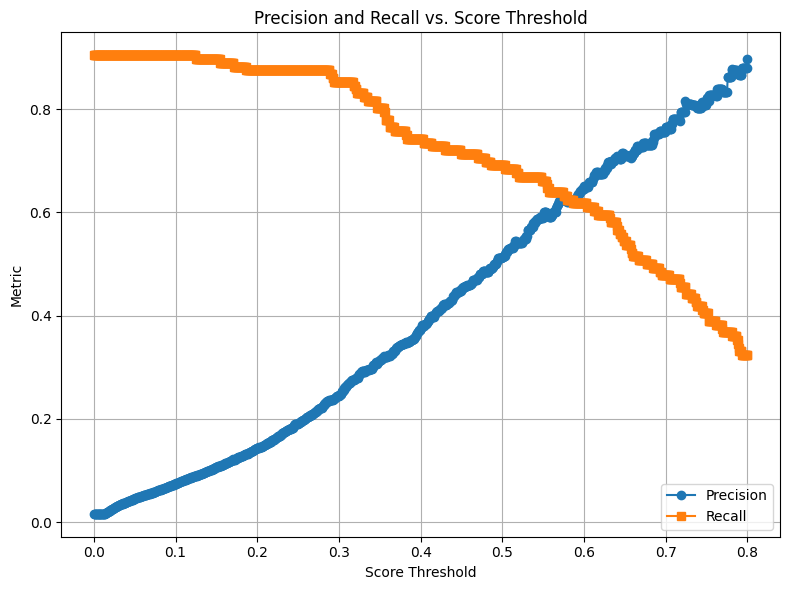

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from cryoet.inference.predict_volume import *
import torch

# Config
score_thresholds_list = np.linspace(0,0.8,1000)
iou_threshold = 0.5
pixel_size = 10.012
box_size = 20
device = 'cuda'
torch_dtype = torch.float16
OUTPUT_DIR = Path("/home/yousef.metwally/Kaggle-2024-CryoET/yoyo_output/TS_5_4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load GT boxes
def read_boxes(filename):
    with open(filename, 'r') as f:
        return [tuple(map(float, line.strip().split())) for line in f]

#ground_truth_boxes = read_boxes('/mnt/data2/D2/generalization_tomogram/coords/gt.coords')
ground_truth_boxes = read_boxes('/mnt/data1/D1/Competition/10440/TS_5_4.coords')

# IoU calculation
def calculate_iou(box1, box2, box_size):
    x1, y1, z1 = box1
    x2, y2, z2 = box2
    x_left = max(x1 - box_size/2, x2 - box_size/2)
    x_right = min(x1 + box_size/2, x2 + box_size/2)
    y_bottom = max(y1 - box_size/2, y2 - box_size/2)
    y_top = min(y1 + box_size/2, y2 + box_size/2)
    z_front = max(z1 - box_size/2, z2 - box_size/2)
    z_back = min(z1 + box_size/2, z2 + box_size/2)
    if x_left < x_right and y_bottom < y_top and z_front < z_back:
        intersection = (x_right - x_left) * (y_top - y_bottom) * (z_back - z_front)
    else:
        intersection = 0
    union = box_size ** 3 * 2 - intersection
    return intersection / union if union != 0 else 0

# Store metrics
precisions, recalls, picks = [], [], []

study_sub = predict_volume(
        volume=volume,
        study_name='TS_5_4',
        output_strides=(2,),
        models=models,
        window_size=(192, 128, 128),
        tiles_per_dim=(1, 9, 9),
        use_weighted_average=True,
        use_centernet_nms=True,
        use_single_label_per_anchor=False,
        pre_nms_top_k=16536*2,
        use_z_flip_tta=False,
        use_y_flip_tta=False,
        use_x_flip_tta=False,
        score_thresholds=[0],
        iou_threshold=0.2,
        batch_size=1,
        num_workers=0,
        device=device,
        torch_dtype=torch_dtype,
    )

for score_threshold in score_thresholds_list:
 

    # Save and format prediction
    CSV_PATH = OUTPUT_DIR / f"submission_thresh_{score_threshold}.csv"
    study_sub[(study_sub['score']>score_threshold)].to_csv(CSV_PATH, index=False)
    submission = pd.read_csv(CSV_PATH)
    submission[['x', 'y', 'z']] = (submission[['x', 'y', 'z']] / pixel_size).astype(int)

    # Save .coords for one class
    group = submission[(submission["experiment"] == "TS_5_4") & (submission["particle_type"] == "apo-ferritin")]
    coords_file = OUTPUT_DIR / f"TS_5_4_{score_threshold}.coords"
    group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

    # Evaluate
    experimental_boxes = read_boxes(coords_file)
    matched = [False] * len(ground_truth_boxes)
    tp = 0

    for exp_box in experimental_boxes:
        best_iou = 0
        best_index = -1
        for i, gt_box in enumerate(ground_truth_boxes):
            if not matched[i]:
                current_iou = calculate_iou(exp_box, gt_box, box_size)
                if current_iou > best_iou:
                    best_iou = current_iou
                    best_index = i
        if best_iou >= iou_threshold:
            tp += 1
            matched[best_index] = True

    precision = tp / len(experimental_boxes) if experimental_boxes else 0.0
    recall = tp / len(ground_truth_boxes) if ground_truth_boxes else 0.0

    print(f"TP: {tp}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    precisions.append(precision)
    recalls.append(recall)
    picks.append(len(experimental_boxes))

# Plotting
plt.figure(figsize=(8,6))
plt.plot(score_thresholds_list, precisions, 'o-', label='Precision')
plt.plot(score_thresholds_list, recalls, 's-', label='Recall')
#plt.plot(score_thresholds_list, picks, 's-', label='Num_picks')
plt.xlabel("Score Threshold")
plt.ylabel("Metric")
plt.title("Precision and Recall vs. Score Threshold")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [86]:
results_df = pd.DataFrame({
    'score_threshold': score_thresholds_list,
    'precision': precisions,
    'recall': recalls,
    'Picks': picks
})
results_df.to_csv('/home/yousef.metwally/Kaggle-2024-CryoET/wbp_output/TS_5_4/threshold_metrics.csv', index=False)


In [ ]:
import pandas as pd
from pathlib import Path
#OUTPUT_DIR = Path("/home/yousef.metwally/Kaggle-2024-CryoET/sim_output/TS_5_4")
#OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = "/home/yousef.metwally/Kaggle-2024-CryoET/sim_output/TS_5_4_sim_0.1_submission.csv"
#study_sub.to_csv(f"{CSV_PATH}", index=False)
submission = pd.read_csv(CSV_PATH)
#pixel_size = 10
#submission[['x', 'y','z']] = submission[['x', 'y','z']] / pixel_size
#submission[['x', 'y','z']] = submission[['x', 'y','z']].astype(int)


#grouped = submission.groupby(['experiment', 'particle_type'])
for (experiment_id, particle_type), group in grouped:
        coords_file = OUTPUT_DIR / f"{experiment_id}_{particle_type}.coords"
        group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')

print(f"Saved .coords files in {OUTPUT_DIR.resolve()}")

# Different stuff

In [ ]:
import os
import shutil
import glob

# Source and destination root directories
src_root = "/mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/TRAINSET_REPO/extracted/rounds32_280p"
dst_root = "/mnt/data2/D2/Sim_trainingdata/simulations"

# Loop over rounds and tomos
for round_num in range(1, 33):  # 1 to 32
    for tomo_num in range(1, 9):  # 1 to 8
        # Source file
        src_file = os.path.join(
            src_root,
            f"tomo_simulation_round_{round_num}",
            f"tomo_0{tomo_num}",
            "particle_positions.txt"
        )

        # Destination folder pattern with wildcard for timestamp
        dst_pattern = os.path.join(
            dst_root,
            f"tomo_simulation_round_{round_num}",
            "out_sim",
            f"tomo_0{tomo_num}.*"  # match any timestamp
        )

        # Use glob to find the matching directory
        matching_dirs = glob.glob(dst_pattern)

        if not os.path.exists(src_file):
            print(f"Missing source: {src_file}")
            continue

        if not matching_dirs:
            print(f"Missing destination directory for: round {round_num}, tomo {tomo_num}")
            continue

        # Pick the first matching directory (or sort and pick if needed)
        dst_tomo_dir = matching_dirs[0]
        dst_file = os.path.join(dst_tomo_dir, "particle_positions.txt")

        shutil.copy2(src_file, dst_file)
        print(f"Copied: {src_file} -> {dst_file}")


Copied: /mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/TRAINSET_REPO/extracted/rounds32_280p/tomo_simulation_round_1/tomo_01/particle_positions.txt -> /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_01.2022-04-11T14:03:27+02:00/particle_positions.txt
Copied: /mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/TRAINSET_REPO/extracted/rounds32_280p/tomo_simulation_round_1/tomo_02/particle_positions.txt -> /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_02.2022-04-11T14:03:27+02:00/particle_positions.txt
Copied: /mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/TRAINSET_REPO/extracted/rounds32_280p/tomo_simulation_round_1/tomo_03/particle_positions.txt -> /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_03.2022-04-11T14:03:27+02:00/particle_positions.txt
Copied: /mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/Data/TRAINSET_REPO/extracted/rounds32_280p/tomo_simul

: 

In [42]:
import pandas as pd

alles = pd.read_csv('/mnt/data1/D1/Competition/10440/all_gt.csv')

In [43]:
alles

,id,experiment,particle_type,x,y,z
0,0,TS_99_9,ribosome,331.554087,546.973662,101.329456
1,1,TS_99_9,ribosome,310.235571,556.752839,118.468832
2,2,TS_99_9,ribosome,367.258978,526.496270,88.968451
3,3,TS_99_9,ribosome,371.272440,544.858704,110.188804
4,4,TS_99_9,ribosome,352.089149,560.769396,111.124272
...,...,...,...,...,...,...
1244,1244,TS_69_2,apo-ferritin,337.068379,453.173759,58.502597
1245,1245,TS_69_2,apo-ferritin,345.921074,475.392492,58.502597
1246,1246,TS_69_2,apo-ferritin,327.685320,426.562220,66.502953
1247,1247,TS_69_2,apo-ferritin,373.360653,428.913225,66.502953


In [44]:
grouped = alles.groupby('experiment')


In [24]:
grouped

In [45]:
from pathlib import Path
import numpy as np
for exp , group in grouped:
   print(exp)
   OUTPUT_DIR = Path(f"/mnt/data2/D2/OD/Data/{exp}/coords")
   OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
   coords_file = OUTPUT_DIR / f"{exp}.coords"
   txt_file = OUTPUT_DIR / 'particle_positions.txt'
   group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')
   x = group[['particle_type','x', 'y', 'z']]
   x["f1"] = 'NaN'
   x["f2"] = 'NaN'
   x["f3"] = 'NaN'
   x.to_csv(txt_file, index=False, header=False, sep=',')

TS_5_4
TS_69_2
TS_6_4
TS_6_6
TS_73_6
TS_86_3
TS_99_9


/tmp/ipykernel_1138627/2763586603.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["f1"] = 'NaN'
/tmp/ipykernel_1138627/2763586603.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["f1"] = 'NaN'
/tmp/ipykernel_1138627/2763586603.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

In [41]:
import shutil
from pathlib import Path

# Set your source directory (where the .mrc files are)
source_dir = Path("/mnt/data2/D2/public_czi_tomos")

# Set your base destination directory
destination_base = Path("/mnt/data2/D2/OD/Data")

# Iterate over all .mrc files in the source directory
for mrc_file in source_dir.glob("*.mrc"):
    # Get the filename without extension
    file_stem = mrc_file.stem  # e.g., TS_1_2 from TS_1_2.mrc

    # Define destination path: /mnt/data2/D2/OD/Data/TS_1_2/tomo/
    destination_dir = destination_base / file_stem / "tomo"
    destination_dir.mkdir(parents=True, exist_ok=True)

    # Define full destination file path
    destination_file = destination_dir / mrc_file.name

    # Copy the file
    shutil.copy2(mrc_file, destination_file)

    print(f"Copied {mrc_file} -> {destination_file}")


Copied /mnt/data2/D2/public_czi_tomos/TS_43_9.mrc -> /mnt/data2/D2/OD/Data/TS_43_9/tomo/TS_43_9.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_53_7.mrc -> /mnt/data2/D2/OD/Data/TS_53_7/tomo/TS_53_7.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_93_9.mrc -> /mnt/data2/D2/OD/Data/TS_93_9/tomo/TS_93_9.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_1_8.mrc -> /mnt/data2/D2/OD/Data/TS_1_8/tomo/TS_1_8.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_109_2.mrc -> /mnt/data2/D2/OD/Data/TS_109_2/tomo/TS_109_2.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_1_7.mrc -> /mnt/data2/D2/OD/Data/TS_1_7/tomo/TS_1_7.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_102_2.mrc -> /mnt/data2/D2/OD/Data/TS_102_2/tomo/TS_102_2.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_65_9.mrc -> /mnt/data2/D2/OD/Data/TS_65_9/tomo/TS_65_9.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_48_5.mrc -> /mnt/data2/D2/OD/Data/TS_48_5/tomo/TS_48_5.mrc
Copied /mnt/data2/D2/public_czi_tomos/TS_60_7.mrc -> /mnt/data2/D2/OD/Data/TS_60_7/tomo/TS_60_7.mrc


In [48]:
import shutil
from pathlib import Path

base_src = Path("/mnt/data2/D2/Sim_trainingdata/simulations")
base_dst = Path("/mnt/data2/D2/OD/Data")

# Loop over 32 rounds
for i in range(1, 33):
    round_dir = base_src / f"tomo_simulation_round_{i}" / "out_sim"

    # Loop over 8 tomograms per round
    for j in range(1, 9):
        tomo_prefix = f"tomo_{j:02d}"

        # Search for folder starting with "tomo_{j:02d}."
        matches = list(round_dir.glob(f"{tomo_prefix}.*"))
        if not matches:
            print(f"[!] No folder found for {tomo_prefix} in round {i}")
            continue

        tomo_dir = matches[0]  # Assume first match is the correct one
        mrc_file = tomo_dir / "reconstruction" / "tiltseries_rec.mrc"
        txt_file = tomo_dir / "particle_positions.txt"
        if not mrc_file.exists():
            print(f"[!] MRC file not found: {mrc_file}")
            continue

        # Destination path
        dst_dir = base_dst / f"round{i}_tomo{j}" / "tomo"
        dst_dir.mkdir(parents=True, exist_ok=True)

        coordspath = base_dst / f"round{i}_tomo{j}" / "coords"
        coordspath.mkdir(parents=True, exist_ok=True)
        # Copy file
        dst_file = dst_dir / "tiltseries_rec.mrc"
        co = coordspath / "particle_positions.txt"

        shutil.copy2(mrc_file, dst_file)
        shutil.copy2(txt_file, co)

        print(f"[✓] Copied: {mrc_file} -> {dst_file}")


[✓] Copied: /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_01.2022-04-11T14:03:27+02:00/reconstruction/tiltseries_rec.mrc -> /mnt/data2/D2/OD/Data/round1_tomo1/tomo/tiltseries_rec.mrc
[✓] Copied: /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_02.2022-04-11T14:03:27+02:00/reconstruction/tiltseries_rec.mrc -> /mnt/data2/D2/OD/Data/round1_tomo2/tomo/tiltseries_rec.mrc
[✓] Copied: /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_03.2022-04-11T14:03:27+02:00/reconstruction/tiltseries_rec.mrc -> /mnt/data2/D2/OD/Data/round1_tomo3/tomo/tiltseries_rec.mrc
[✓] Copied: /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_04.2022-04-11T17:02:38+02:00/reconstruction/tiltseries_rec.mrc -> /mnt/data2/D2/OD/Data/round1_tomo4/tomo/tiltseries_rec.mrc
[✓] Copied: /mnt/data2/D2/Sim_trainingdata/simulations/tomo_simulation_round_1/out_sim/tomo_05.2022-04-11T17:02:38+02:00/reconstruct

In [ ]:
os.listdir('/mnt/data2/D2/OD/Data/train')

['TS_98_1', 'round23_tomo4']

: 

In [2]:
# get coords for every particle alone
import pandas as pd
from pathlib import Path
import numpy as np

alles = pd.read_csv('/mnt/data2/D2/10445/all_gt_repeated.csv')

grouped = alles.groupby(['experiment', 'particle_type'])

for (experiment_id, particle_type), group in grouped:
        OUTPUT_DIR = Path(f"/mnt/billy/abt3/group/agraunser/Group-SPHIRE/TomoTwin/CZI_Picking_Competition/debugging_after_ariana/GT_separate_particles/{experiment_id}/")
        OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
        coords_file = OUTPUT_DIR / f"{particle_type}.coords"
        group[['x', 'y', 'z']].to_csv(coords_file, index=False, header=False, sep=' ')
